Бернулли(p=0.6)      | Асимметрия:   -0.320 | Эксцесс:   -1.900 | Истинная асимметрия: -0.408 | Истинный эксцесс: -1.833
Биномиальное(n=10,p=0.4) | Асимметрия:    0.119 | Эксцесс:   -0.111 | Истинная асимметрия: 0.129 | Истинный эксцесс: -0.183
Геометрическое(p=0.3) | Асимметрия:    2.182 | Эксцесс:    6.734 | Истинная асимметрия: 2.032 | Истинный эксцесс: 6.129
Пуассона(lambd=3)    | Асимметрия:    0.621 | Эксцесс:    0.444 | Истинная асимметрия: 0.577 | Истинный эксцесс: 0.333
Равномерное [0,1]    | Асимметрия:    0.071 | Эксцесс:   -1.207 | Истинная асимметрия: 0.000 | Истинный эксцесс: -1.200
экспоненциальное(alpha=2) | Асимметрия:    1.965 | Эксцесс:    5.525 | Истинная асимметрия: 2.000 | Истинный эксцесс: 6.000
Лапласа(alpha=1)     | Асимметрия:    0.101 | Эксцесс:    2.652 | Истинная асимметрия: 0.000 | Истинный эксцесс: 3.000
Нормальное(0,1)      | Асимметрия:   -0.136 | Эксцесс:   -0.158 | Истинная асимметрия: 0.000 | Истинный эксцесс: 0.000
Коши                 | Асимметрия:

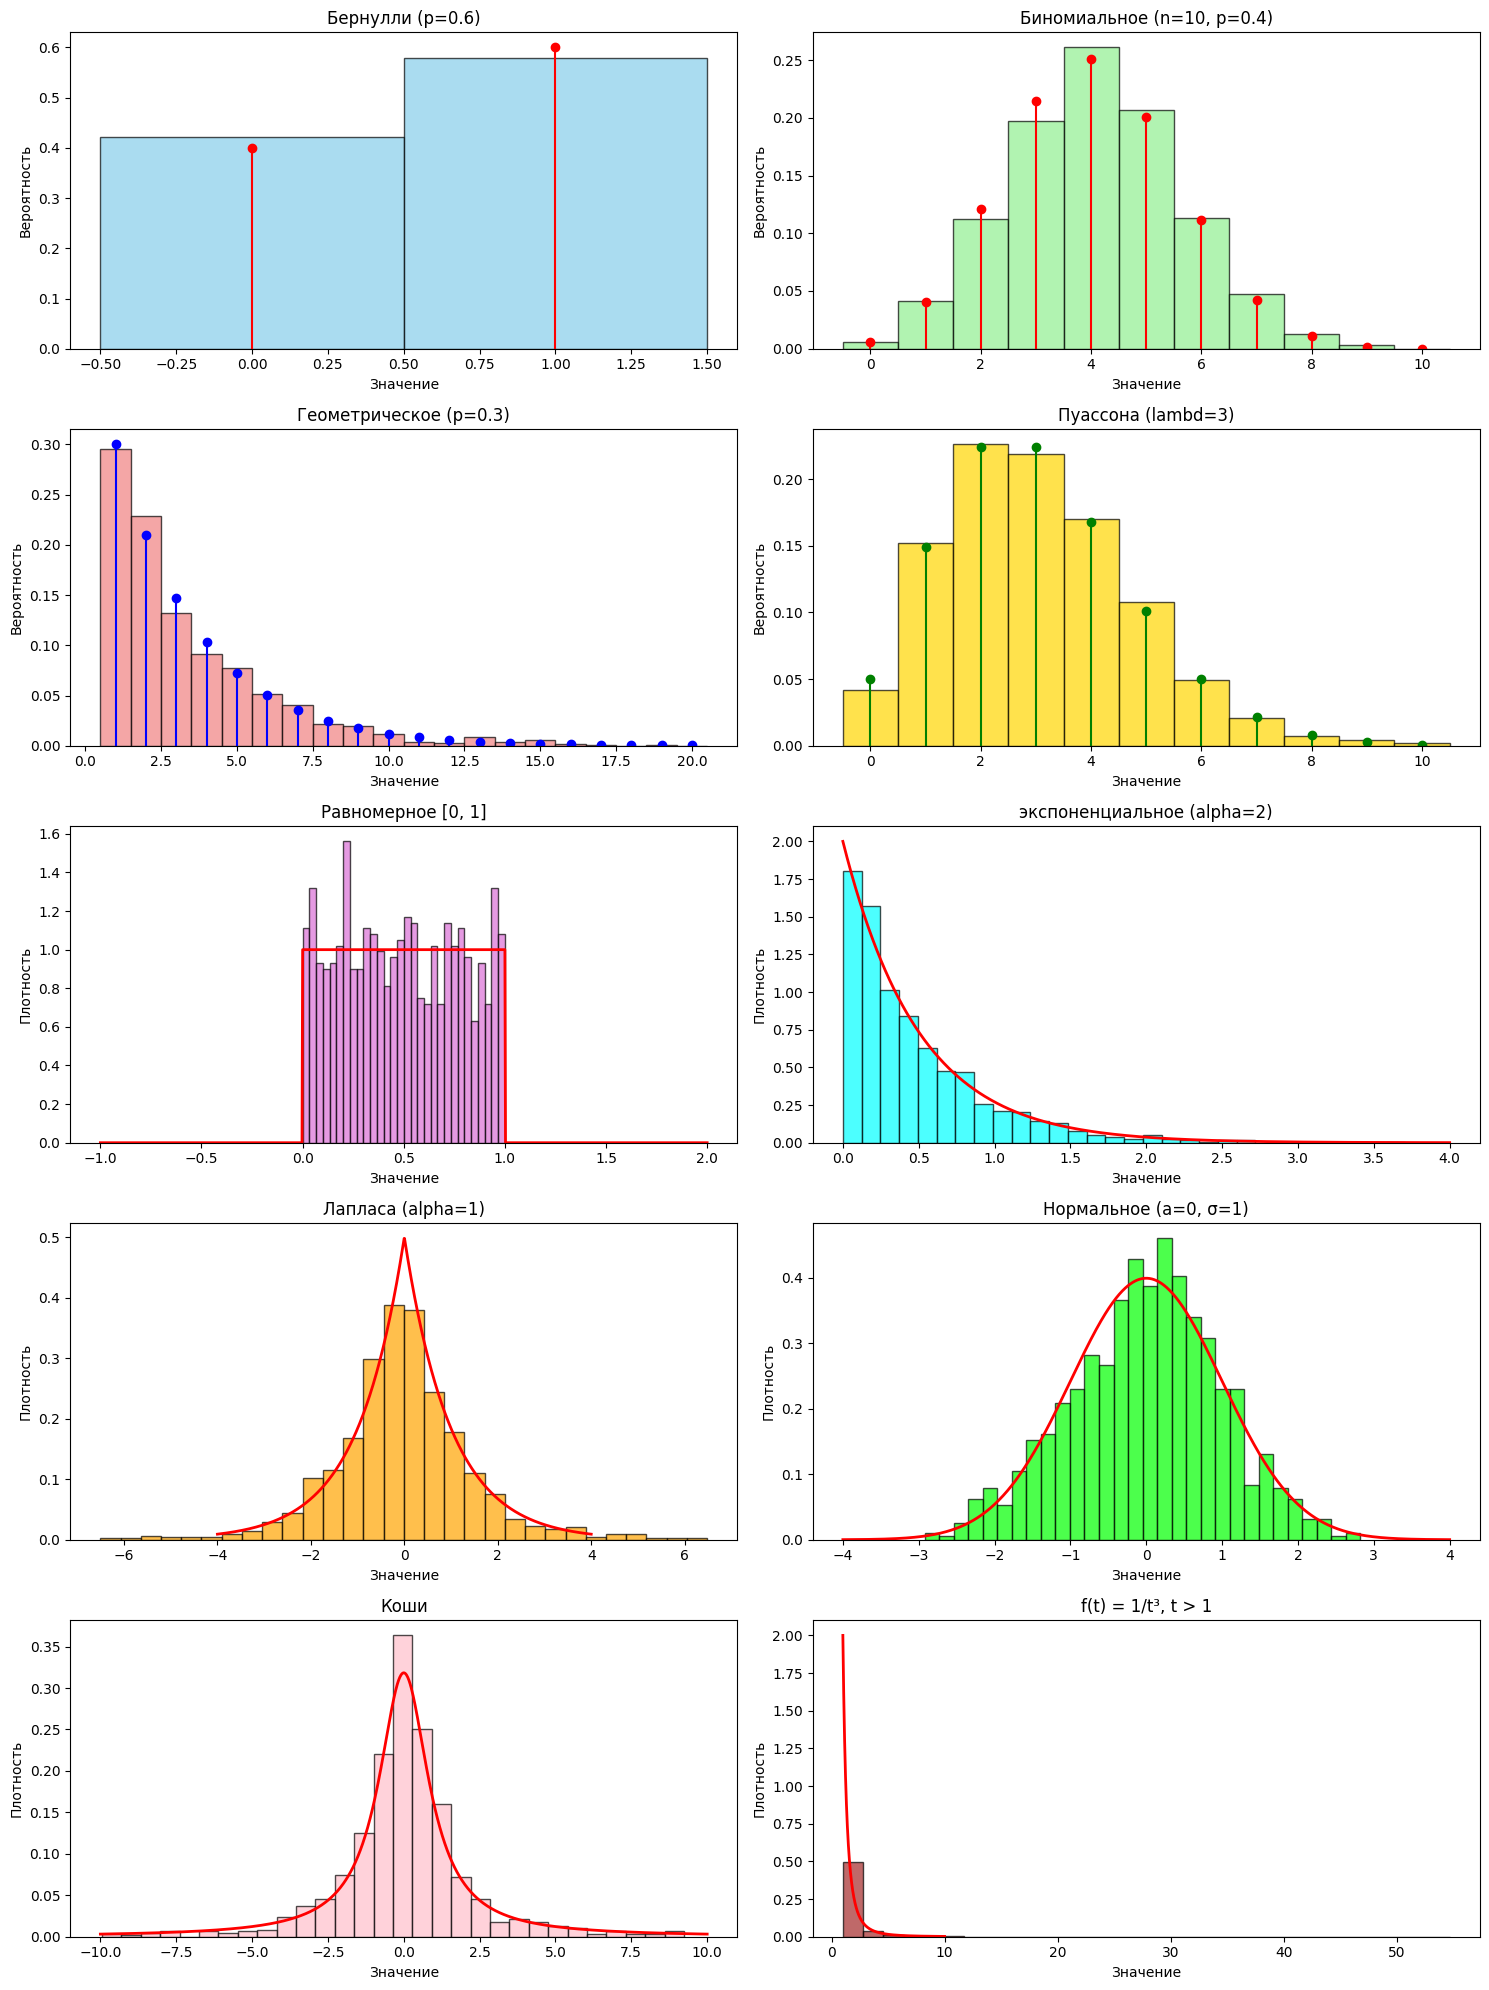

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import exp, log, sqrt


# Выборочный коэффициент асимметрии
def sample_skewness(data):
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # ddof=1 для несмещенной оценки
    skew = np.sum((data - mean) ** 3) / n / (std**3)
    return skew
# Выборочный коэффициент эксцесса
def sample_kurtosis(data):
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    kurt = np.sum((data - mean) ** 4) / n / (std**4) - 3
    return kurt


def analyze_distribution(name, samples, true_skew=None, true_kurt=None):
    skew = sample_skewness(samples)
    kurt = sample_kurtosis(samples)

    print(f"{name:20} | Асимметрия: {skew:8.3f} | Эксцесс: {kurt:8.3f}", end="")
    if true_skew is not None:
        print(f" | Истинная асимметрия: {true_skew:.3f}", end="")
    if true_kurt is not None:
        print(f" | Истинный эксцесс: {true_kurt:.3f}", end="")
    print()


# Бернулли с параметром p
def bernoulli(p, size=1):
    u = np.random.uniform(0, 1, size)
    return (u <= p).astype(int)


# Биномиальное с параметрами n, p
def binomial(n, p, size=1):
    if size == 1:
        return np.sum(bernoulli(p, n))
    else:
        return np.array([np.sum(bernoulli(p, n)) for _ in range(size)])


# Геометрическое с параметром p
def geometric(p, size=1):
    u = np.random.uniform(0, 1, size)
    return np.floor(np.log(u) / np.log(1 - p)).astype(int) + 1


# Пуассона с параметром lambd
def poisson(lambd, size=1):
    def single_poisson():
        u = np.random.uniform()
        k = 0
        p = exp(-lambd)
        F = p
        while u > F:
            k += 1
            p *= lambd / k
            F += p
        return k

    if size == 1:
        return single_poisson()
    else:
        #тоже фиговина для ускорения чтобы не счиать много while циклов
        return np.array([single_poisson() for _ in range(size)])


# Равномерное на отрезке [a, b]
def uniform(a, b, size=1):
    u = np.random.uniform(0, 1, size)
    return a + (b - a) * u


# экспоненциальное с параметром alpha
def exponential(alpha, size=1):
    u = np.random.uniform(0, 1, size)
    return -np.log(1 - u) / alpha


# Лапласа с параметром alpha
def laplace(alpha, size=1):
    u = np.random.uniform(0, 1, size)
    return np.where(u < 0.5, np.log(2 * u) * alpha, -np.log(2 * (1 - u)) * alpha)


# Нормальное с параметрами a и sigma^2
# нашла какой-то алгоритм для ускорения этого дела где считается две величины одновременно
# алгоритм Бокс-Мюллер. не разбирала подробно, но вроде он равномерные величины преобразует в нормальное
def normal(a, sigma, size=1):
    if size == 1:
        u1, u2 = np.random.uniform(0, 1, 2)
        z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
        return a + sigma * z0
    else:
        result = []
        for _ in range((size + 1) // 2):
            u1, u2 = np.random.uniform(0, 1, 2)
            z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
            z1 = sqrt(-2 * log(u1)) * np.sin(2 * np.pi * u2)
            result.extend([a + sigma * z0, a + sigma * z1])
        return np.array(result[:size])


# Распределение Коши
def cauchy(size=1):
    u = np.random.uniform(0, 1, size)
    return np.tan(np.pi * (u - 0.5))


# Распределение с ядром f(t) = 1/t^3 I{t>1}
def custom_distribution(size=1):
    u = np.random.uniform(0, 1, size)
    return 1 / np.sqrt(1 - u)

sample_size = 1000

# Функция для построения графиков
def plot_distributions():
    np.random.seed(49) 
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    axes = axes.flatten()

    # Бернулли
    p_bern = 0.6
    sample_bern = bernoulli(p_bern, 1000)
    axes[0].hist(
        sample_bern,
        bins=[-0.5, 0.5, 1.5],
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
    )
    x_bern = [0, 1]
    pmf_bern = [(1 - p_bern), p_bern]
    axes[0].stem(x_bern, pmf_bern, linefmt="r-", markerfmt="ro", basefmt=" ")
    axes[0].set_title(f"Бернулли (p={p_bern})")
    axes[0].set_xlabel("Значение")
    axes[0].set_ylabel("Вероятность")

    true_skew = (
        (1 - 2 * p_bern) / sqrt(p_bern * (1 - p_bern))
        if p_bern * (1 - p_bern) > 0
        else 0
    )
    true_kurt = (
        (1 - 6 * p_bern * (1 - p_bern)) / (p_bern * (1 - p_bern))
        if p_bern * (1 - p_bern) > 0
        else 0
    )
    analyze_distribution(f"Бернулли(p={p_bern})", sample_bern, true_skew, true_kurt)

    # Биномиальное
    n_binom, p_binom = 10, 0.4
    sample_binom = binomial(n_binom, p_binom, 1000)
    bins_binom = np.arange(-0.5, n_binom + 1.5, 1)
    axes[1].hist(
        sample_binom,
        bins=bins_binom,
        density=True,
        alpha=0.7,
        color="lightgreen",
        edgecolor="black",
    )
    x_binom = np.arange(0, n_binom + 1)
    pmf_binom = stats.binom.pmf(x_binom, n_binom, p_binom)
    axes[1].stem(x_binom, pmf_binom, linefmt="r-", markerfmt="ro", basefmt=" ")
    axes[1].set_title(f"Биномиальное (n={n_binom}, p={p_binom})")
    axes[1].set_xlabel("Значение")
    axes[1].set_ylabel("Вероятность")

    true_skew = (1 - 2 * p_binom) / sqrt(n_binom * p_binom * (1 - p_binom))
    true_kurt = (1 - 6 * p_binom * (1 - p_binom)) / (n_binom * p_binom * (1 - p_binom))
    analyze_distribution(
        f"Биномиальное(n={n_binom},p={p_binom})", sample_binom, true_skew, true_kurt
    )

    #Геометрическое
    p_geom = 0.3
    sample_geom = geometric(p_geom, 1000)
    max_geom = min(20, np.max(sample_geom))
    bins_geom = np.arange(0.5, max_geom + 1.5, 1)
    axes[2].hist(
        sample_geom,
        bins=bins_geom,
        density=True,
        alpha=0.7,
        color="lightcoral",
        edgecolor="black",
    )
    x_geom = np.arange(1, max_geom + 1)
    pmf_geom = p_geom * (1 - p_geom) ** (x_geom - 1)
    axes[2].stem(x_geom, pmf_geom, linefmt="b-", markerfmt="bo", basefmt=" ")
    axes[2].set_title(f"Геометрическое (p={p_geom})")
    axes[2].set_xlabel("Значение")
    axes[2].set_ylabel("Вероятность")

    true_skew = (2 - p_geom) / sqrt(1 - p_geom)
    true_kurt = 6 + (p_geom**2) / (1 - p_geom)
    analyze_distribution(
        f"Геометрическое(p={p_geom})", sample_geom, true_skew, true_kurt
    )

    #Пуассона
    lambda_poiss = 3
    sample_poiss = poisson(lambda_poiss, 1000)
    max_poiss = min(15, np.max(sample_poiss))
    bins_poiss = np.arange(-0.5, max_poiss + 1.5, 1)
    axes[3].hist(
        sample_poiss,
        bins=bins_poiss,
        density=True,
        alpha=0.7,
        color="gold",
        edgecolor="black",
    )
    x_poiss = np.arange(0, max_poiss + 1)
    pmf_poiss = stats.poisson.pmf(x_poiss, lambda_poiss)
    axes[3].stem(x_poiss, pmf_poiss, linefmt="g-", markerfmt="go", basefmt=" ")
    axes[3].set_title(f"Пуассона (lambd={lambda_poiss})")
    axes[3].set_xlabel("Значение")
    axes[3].set_ylabel("Вероятность")
    true_skew = 1 / sqrt(lambda_poiss)
    true_kurt = 1 / lambda_poiss
    analyze_distribution(
        f"Пуассона(lambd={lambda_poiss})", sample_poiss, true_skew, true_kurt
    )

    # Равномерное
    a_unif, b_unif = 0, 1
    sample_unif = uniform(a_unif, b_unif, 1000)
    axes[4].hist(
        sample_unif, bins=30, density=True, alpha=0.7, color="orchid", edgecolor="black"
    )
    x_unif = np.linspace(a_unif - 1, b_unif + 1, 1000)
    pdf_unif = np.where(
        (x_unif >= a_unif) & (x_unif <= b_unif), 1 / (b_unif - a_unif), 0
    )
    axes[4].plot(x_unif, pdf_unif, "r-", linewidth=2)
    axes[4].set_title(f"Равномерное [{a_unif}, {b_unif}]")
    axes[4].set_xlabel("Значение")
    axes[4].set_ylabel("Плотность")
    analyze_distribution("Равномерное [0,1]", sample_unif, 0, -1.2)

    # экспоненциальное
    alpha_exp = 2
    sample_exp = exponential(alpha_exp, 1000)
    axes[5].hist(
        sample_exp, bins=30, density=True, alpha=0.7, color="cyan", edgecolor="black"
    )
    x_exp = np.linspace(0, 4, 1000)
    pdf_exp = alpha_exp * np.exp(-alpha_exp * x_exp)
    axes[5].plot(x_exp, pdf_exp, "r-", linewidth=2)
    axes[5].set_title(f"экспоненциальное (alpha={alpha_exp})")
    axes[5].set_xlabel("Значение")
    axes[5].set_ylabel("Плотность")
    analyze_distribution(f"экспоненциальное(alpha={alpha_exp})", sample_exp, 2, 6)

    # Лапласа
    alpha_laplace = 1
    sample_laplace = laplace(alpha_laplace, 1000)
    axes[6].hist(
        sample_laplace,
        bins=30,
        density=True,
        alpha=0.7,
        color="orange",
        edgecolor="black",
    )
    x_laplace = np.linspace(-4, 4, 1000)
    pdf_laplace = 0.5 * alpha_laplace * np.exp(-alpha_laplace * np.abs(x_laplace))
    axes[6].plot(x_laplace, pdf_laplace, "r-", linewidth=2)
    axes[6].set_title(f"Лапласа (alpha={alpha_laplace})")
    axes[6].set_xlabel("Значение")
    axes[6].set_ylabel("Плотность")
    analyze_distribution("Лапласа(alpha=1)", sample_laplace, 0, 3)

    #Нормальное
    a_norm, sigma_norm = 0, 1
    sample_norm = normal(a_norm, sigma_norm, 1000)
    axes[7].hist(
        sample_norm, bins=30, density=True, alpha=0.7, color="lime", edgecolor="black"
    )
    x_norm = np.linspace(a_norm - 4 * sigma_norm, a_norm + 4 * sigma_norm, 1000)
    pdf_norm = stats.norm.pdf(x_norm, a_norm, sigma_norm)
    axes[7].plot(x_norm, pdf_norm, "r-", linewidth=2)
    axes[7].set_title(f"Нормальное (a={a_norm}, σ={sigma_norm})")
    axes[7].set_xlabel("Значение")
    axes[7].set_ylabel("Плотность")
    analyze_distribution("Нормальное(0,1)", sample_norm, 0, 0)

    #Коши
    sample_cauchy = cauchy(1000)
    # ограничить диапазон а то ничего не видно
    # ask а надо ли анализ распределения проводить на органиченной или нет
    # по идее нет, просто тогда визуально не так понятно мб
    sample_cauchy_trimmed = sample_cauchy[(sample_cauchy > -10) & (sample_cauchy < 10)]
    axes[8].hist(
        sample_cauchy_trimmed,
        bins=30,
        density=True,
        alpha=0.7,
        color="pink",
        edgecolor="black",
    )
    x_cauchy = np.linspace(-10, 10, 1000)
    pdf_cauchy = 1 / (np.pi * (1 + x_cauchy**2))
    axes[8].plot(x_cauchy, pdf_cauchy, "r-", linewidth=2)
    axes[8].set_title("Коши")
    axes[8].set_xlabel("Значение")
    axes[8].set_ylabel("Плотность")
    analyze_distribution("Коши", sample_cauchy)

    # Пользовательское распределение
    sample_custom = custom_distribution(1000)
    axes[9].hist(
        sample_custom,
        bins=30,
        density=True,
        alpha=0.7,
        color="brown",
        edgecolor="black",
    )
    x_custom = np.linspace(1, 10, 1000)
    pdf_custom = 2 / (x_custom**3) 
    axes[9].plot(x_custom, pdf_custom, "r-", linewidth=2)
    axes[9].set_title("f(t) = 1/t³, t > 1")
    axes[9].set_xlabel("Значение")
    axes[9].set_ylabel("Плотность")

    analyze_distribution("Пользовательское", sample_custom)

    plt.tight_layout()
    plt.show()

plot_distributions()

Гамма(shape=1,scale=2) | Асимметрия:    2.172 | Эксцесс:    7.440 | Истинная асимметрия: 2.000 | Истинный эксцесс: 6.000
Бета(a=0.5,b=0.5)    | Асимметрия:    0.064 | Эксцесс:   -1.513 | Истинная асимметрия: 0.000 | Истинный эксцесс: -1.500


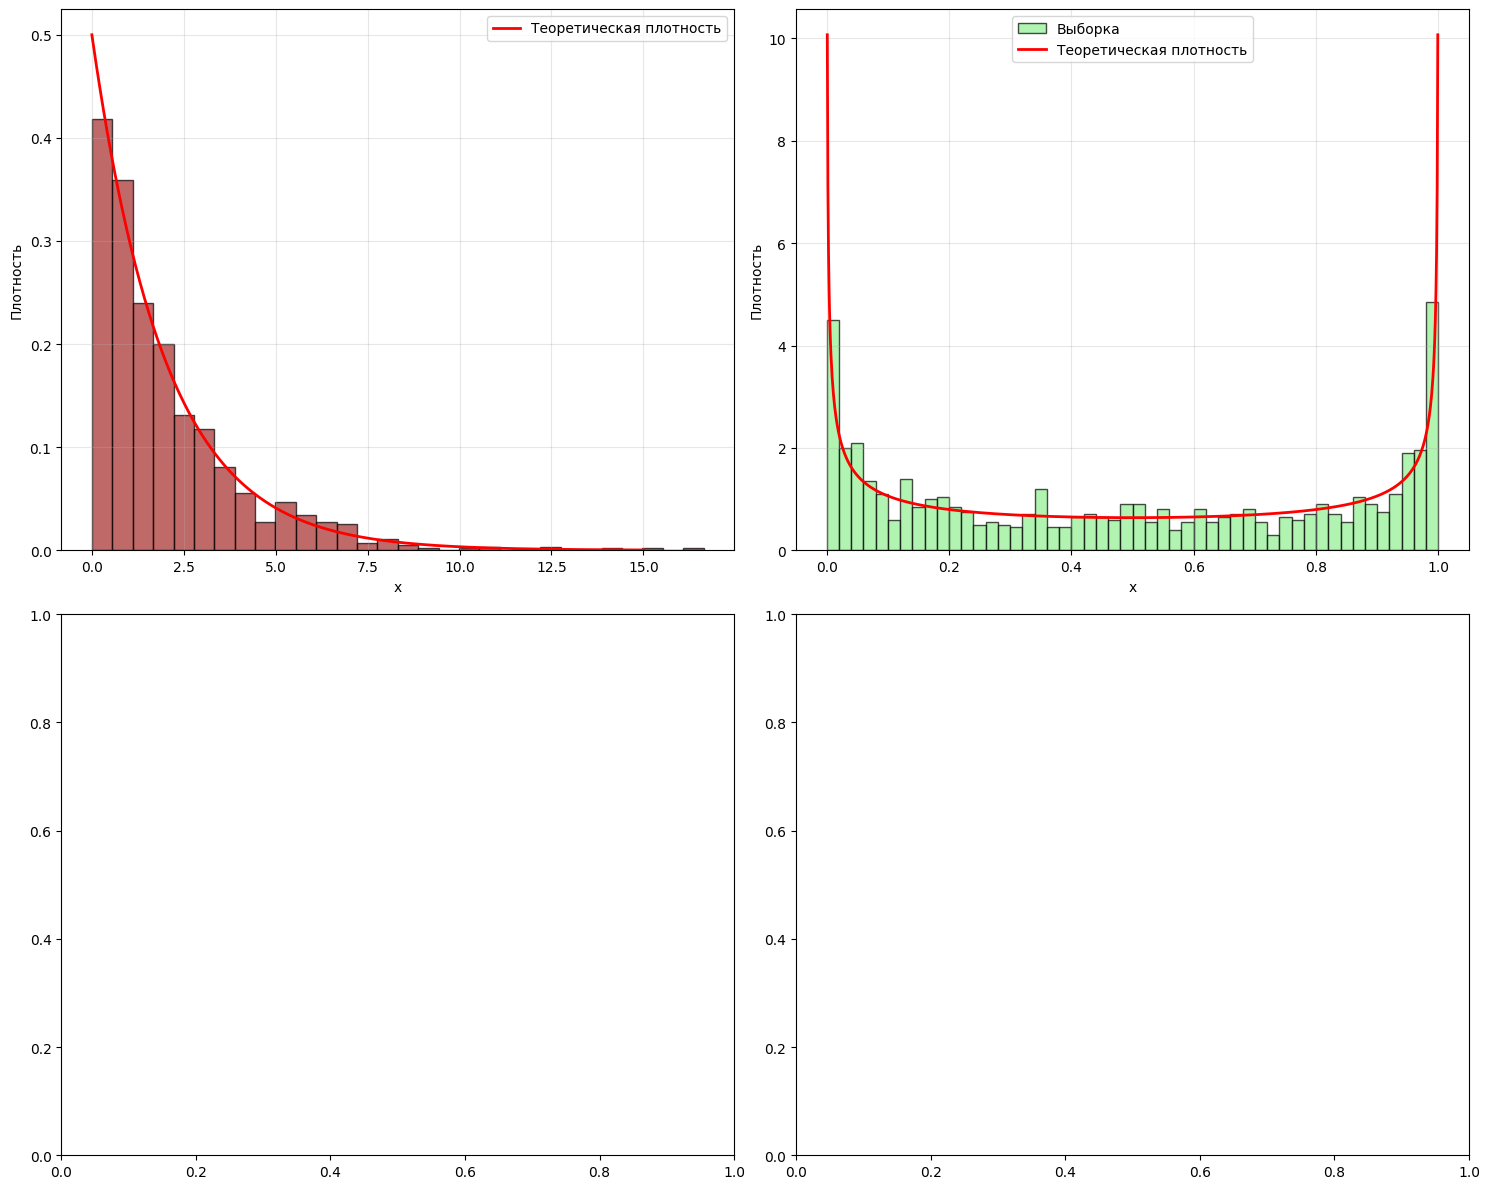

In [2]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

shape, scale = 1, 2
sample_gamma = np.random.gamma(shape, scale, sample_size)
true_skew = 2 / sqrt(shape)
true_kurt = 6 / shape
analyze_distribution(f"Гамма(shape={shape},scale={scale})", sample_gamma, true_skew, true_kurt)

x_gamma = np.linspace(0, 15, 1000)
pdf_gamma = stats.gamma.pdf(x_gamma, shape, scale=scale)
ax1.hist(
        sample_gamma,
        bins=30,
        density=True,
        alpha=0.7,
        color="brown",
        edgecolor="black",
)
ax1.plot(x_gamma, pdf_gamma, 'r-', linewidth=2, label='Теоретическая плотность')
ax1.set_xlabel("x")
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True, alpha=0.3)


a, b = 0.5, 0.5
#при одинаковых будет 0 ассиметрия
# а можно еще b > a и тогда будет вправо ассиметрия
samples_beta = np.random.beta(a, b, sample_size)
true_skew = 2*(b - a)*sqrt(a + b + 1) / ((a + b + 2)*sqrt(a*b))
true_kurt = 6*((a - b)**2*(a + b + 1) - a*b*(a + b + 2)) / (a*b*(a + b + 2)*(a + b + 3))
analyze_distribution(f"Бета(a={a},b={b})", samples_beta, true_skew, true_kurt)

x_beta = np.linspace(0.001, 0.999, 1000)
pdf_beta = stats.beta.pdf(x_beta, a, b)

ax2.hist(samples_beta, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black', label='Выборка')
ax2.plot(x_beta, pdf_beta, 'r-', linewidth=2, label='Теоретическая плотность')
ax2.set_xlabel('x')
ax2.set_ylabel('Плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

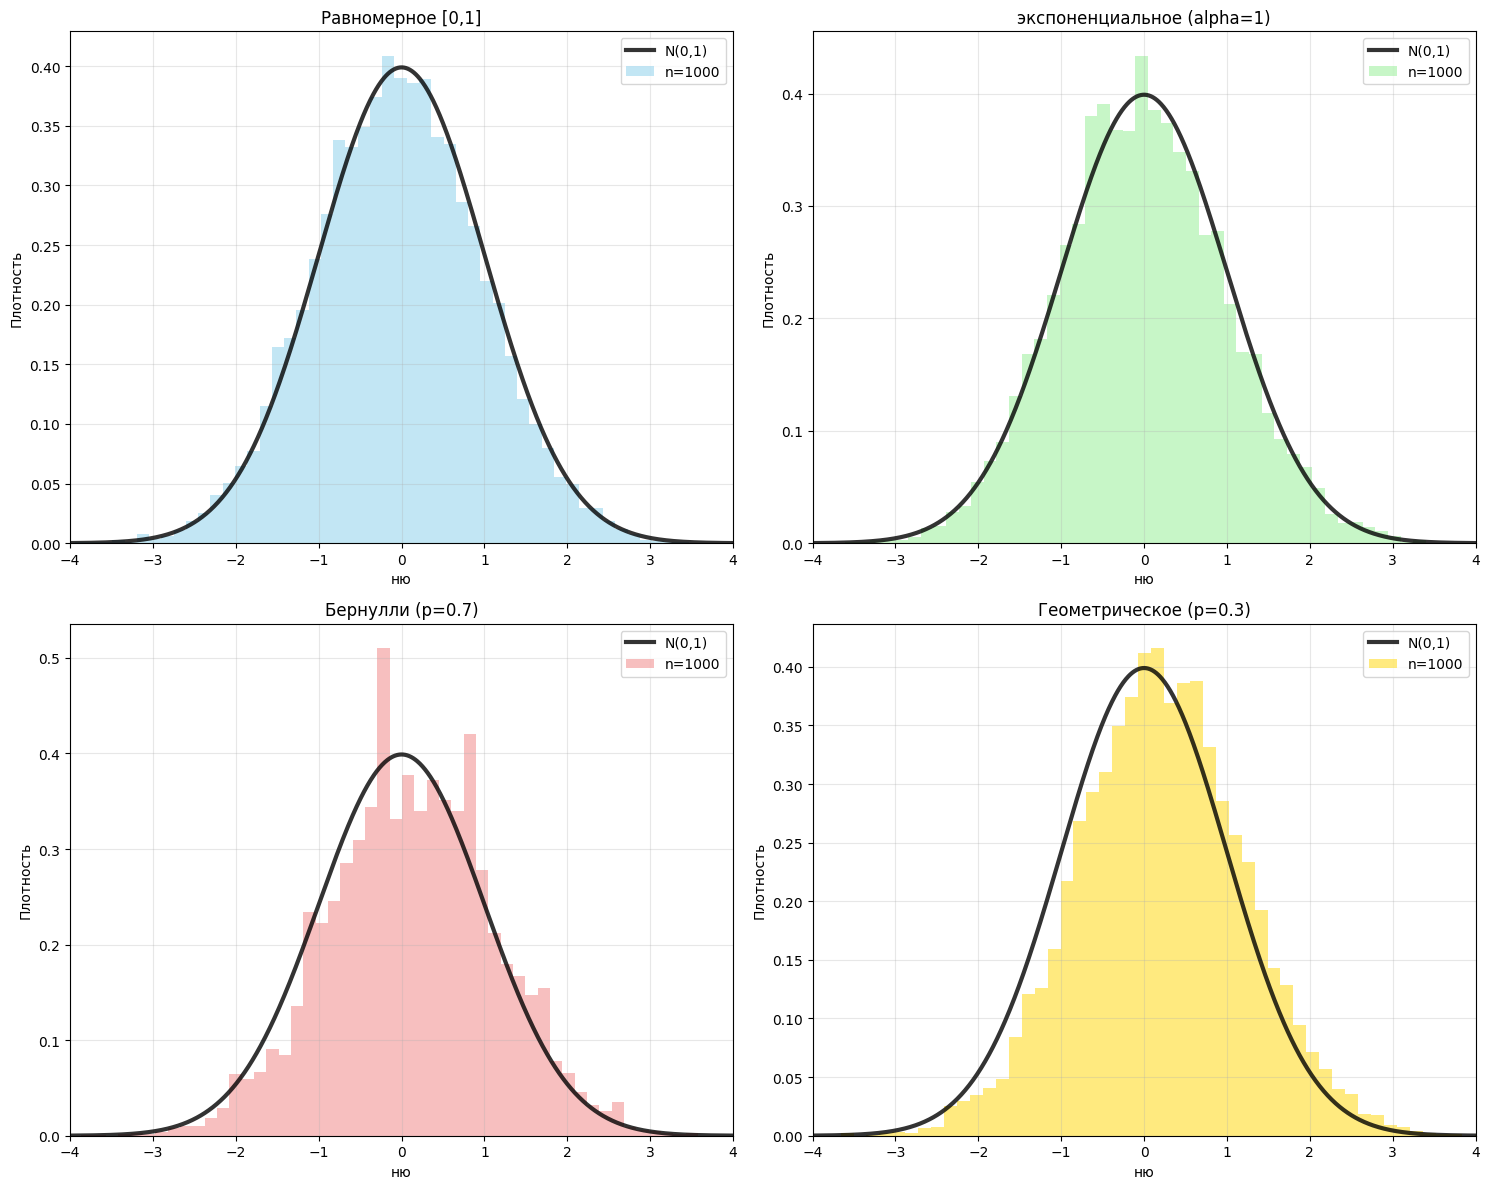

In [10]:
def generate_normal_by_clt_custom(base_distribution, n, N=1, **dist_params):
    all_samples = []
    for i in range(N):
        samples_sequence = base_distribution(size=n, **dist_params)
        all_samples.append(samples_sequence)

    samples = np.array(all_samples)

    large_sample = base_distribution(size=100000, **dist_params)
    E_xi = np.mean(large_sample)
    D_xi = np.var(large_sample)

    sums = np.sum(samples, axis=1)

    eta = (sums - n * E_xi) / np.sqrt(n * D_xi)

    return eta

def clt_demonstration_custom():
    N = 10000 
    #n_values = [1, 5, 10, 30, 100]
    n_values=[1000]

    distributions = [
        {
            "name": "Равномерное [0,1]",
            "func": uniform,
            "params": {"a": 0, "b": 1},
            "color": "skyblue"
        },
        {
            "name": "экспоненциальное (alpha=1)",
            "func": exponential,
            "params": {"alpha": 1},
            "color": "lightgreen"
        },
        {
            "name": "Бернулли (p=0.7)",
            "func": bernoulli,
            "params": {"p": 0.7},
            "color": "lightcoral"
        },
        {
            "name": "Геометрическое (p=0.3)",
            "func": geometric,
            "params": {"p": 0.3},
            "color": "gold"
        },
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, dist in enumerate(distributions):
        ax = axes[idx]

        # норм распр для сравнения
        x = np.linspace(-4, 4, 1000)
        pdf_normal = stats.norm.pdf(x, 0, 1)
        ax.plot(x, pdf_normal, "k-", linewidth=3, label="N(0,1)", alpha=0.8)

        for n in n_values:
            # генерация много выборок и из них ню
            eta_samples= generate_normal_by_clt_custom(
                dist["func"], n, N, **dist["params"]
            )
            ax.hist(
                eta_samples,
                bins=50,
                density=True,
                alpha=0.5,
                label=f"n={n}",
                color=dist["color"],
            )
        ax.set_title(f'{dist["name"]}')
        ax.set_xlabel("ню")
        ax.set_ylabel("Плотность")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-4, 4)

    plt.tight_layout()
    plt.show()

clt_demonstration_custom()

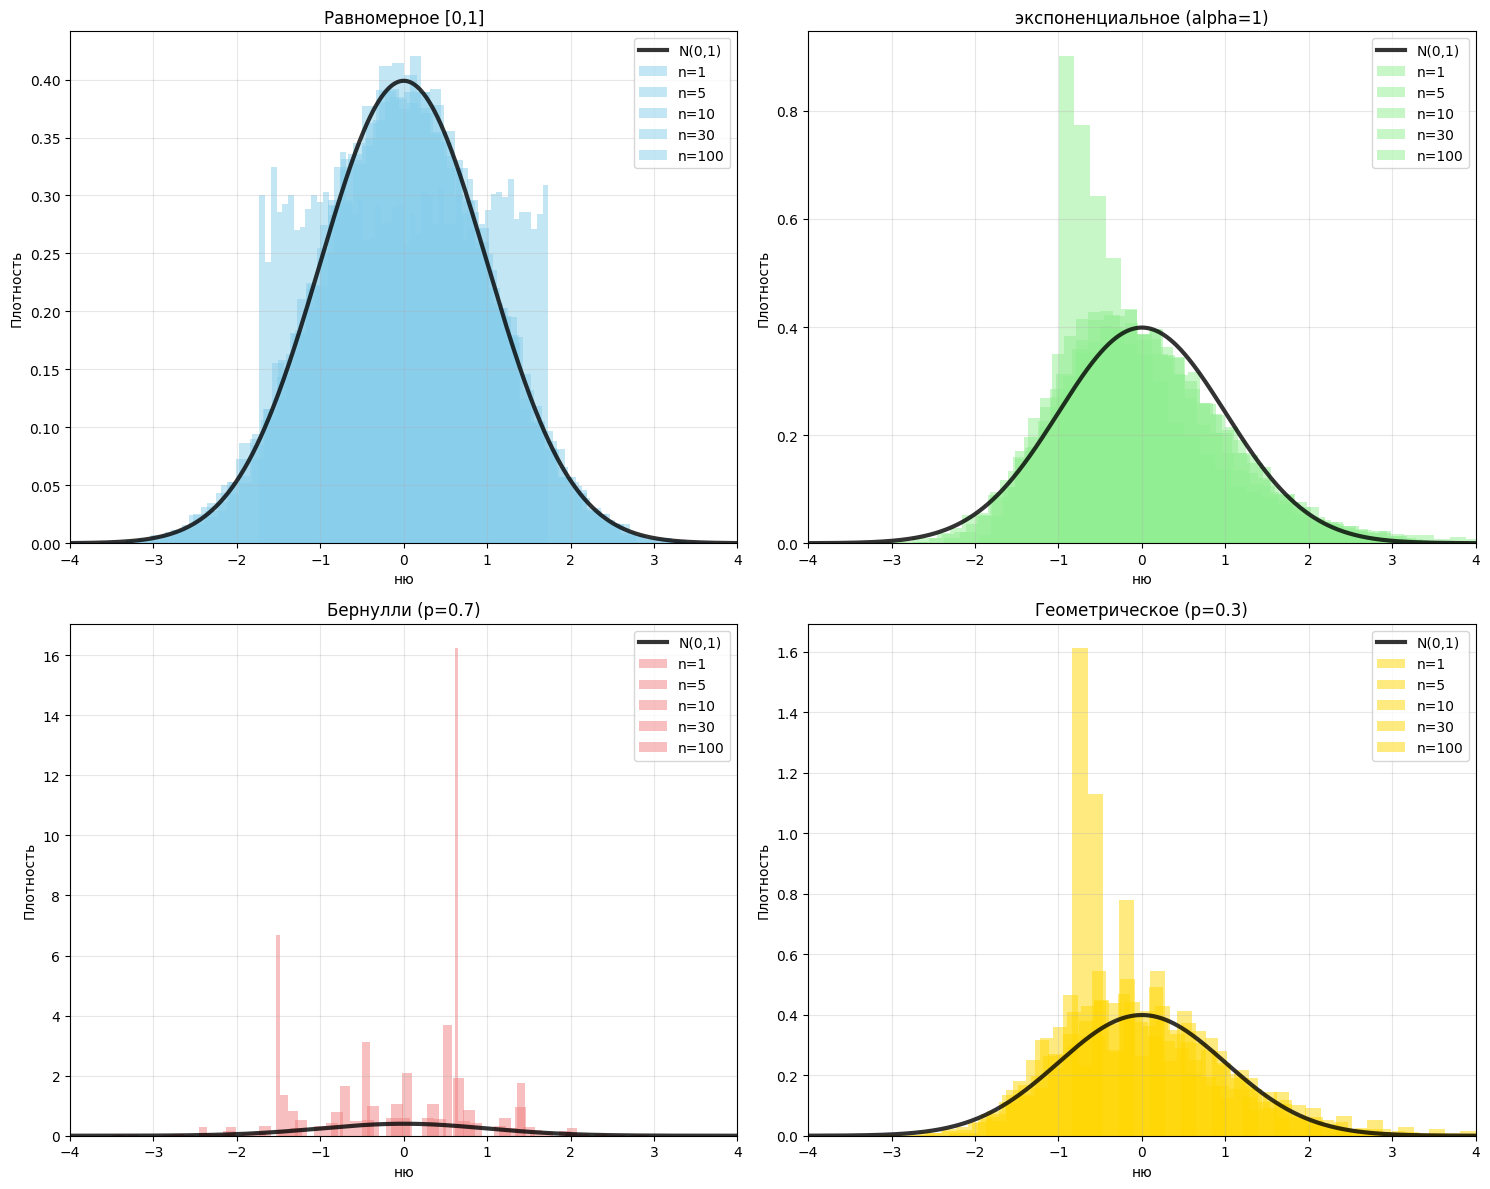

In [8]:
clt_demonstration_custom()